In [ ]:
import sys
sys.path.append('../')
from src.utils import load_project_data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# This notebook served us as a space to explore the problem and test some basic solutions

In [2]:
# loading the data stored in the data folder
X_train, y_train, X_test = load_project_data()

In [3]:
X_train.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V491,V492,V493,V494,V495,V496,V497,V498,V499,V500
0,0.039150,0.090297,8.718609,0.283605,0.202680,0.610760,0.398208,0.515339,0.543217,1.295654,...,-0.315379,0.978128,0.601405,-0.296362,6.592342,0.362233,0.485798,14.675954,0.363195,0.636271
1,0.014734,0.163016,6.199305,0.408763,-4.533185,0.636281,0.493518,0.264718,0.150322,0.137736,...,-0.074720,0.914050,0.313070,-0.101719,9.623047,0.307878,0.274723,13.537626,0.111989,0.174803
2,0.212040,0.202351,17.605414,0.894004,-2.972050,0.987643,0.132025,0.777676,0.698939,-1.173488,...,-0.558201,0.669280,0.130629,0.352382,7.299213,-0.546493,0.003212,5.685340,-0.293000,0.669224
3,0.247885,0.536627,16.829588,0.951665,-0.535890,0.206349,0.017372,0.204348,0.323816,-0.782782,...,-0.326153,0.001555,0.896866,-0.163199,7.226715,0.205496,0.993407,6.836309,-0.978220,0.356167
4,0.954966,0.262058,13.024107,0.210252,1.698029,0.141863,0.343728,0.839255,0.227931,1.206952,...,-0.190742,0.495831,0.782238,-2.465254,14.617433,0.626081,0.401244,5.534338,0.509947,0.357255


In [4]:
X_test.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V491,V492,V493,V494,V495,V496,V497,V498,V499,V500
0,0.755510,0.802075,11.605560,0.599524,-1.039669,0.973491,0.985260,0.614207,0.532860,-0.727321,...,-2.202225,0.128681,0.647653,-1.704865,13.226264,0.225600,0.968926,6.617666,1.082746,0.127283
1,0.154195,0.497673,13.779410,0.464435,-1.609018,0.320622,0.086936,0.720433,0.246680,0.286213,...,-0.643372,0.062225,0.001583,-2.358619,6.555197,0.094808,0.954901,18.235789,-0.433573,0.440953
2,0.443083,0.096503,14.076321,0.364516,-0.417717,0.296597,0.721686,0.108731,0.190864,-1.306112,...,-1.642022,0.825986,0.113188,0.695278,30.030428,-0.345625,0.506275,15.141557,-0.165921,0.185859
3,0.156598,0.610178,8.464675,0.954543,1.577633,0.194383,0.948848,0.990068,0.134768,-0.401710,...,-0.952346,0.065675,0.810703,-0.588008,16.624215,-0.368999,0.595098,12.580407,-1.325349,0.509363
4,0.250420,0.612322,8.420397,0.908849,3.744589,0.111754,0.243412,0.723913,0.427785,1.401647,...,-0.312489,0.054495,0.339066,-1.293212,7.802833,0.369933,0.525994,8.939272,0.903775,0.769899


In [5]:
y_train.head()

,y
0,0
1,1
2,0
3,1
4,0


Target distribution

In [6]:
# target value is balanced
target_counts = y_train['y'].value_counts(normalize=True) * 100
print(target_counts)

y
0    50.24
1    49.76
Name: proportion, dtype: float64


Missing values and constant features

In [7]:
# there are no missing values in the dataset
missing_values = X_train.isnull().sum()
cols_with_missing = missing_values[missing_values > 0]
print(f"\nVariables with missing values: {len(cols_with_missing)}")

unique_counts = X_train.nunique()
constant_features = unique_counts[unique_counts <= 1].index.tolist()
print(f"Variables with constant values: {len(constant_features)}")


Variables with missing values: 0
Variables with constant values: 0


Correlations

In [8]:
df_eda = pd.concat([X_train, y_train], axis=1)

correlations = df_eda.corr()['y'].drop('y')
top_correlations = correlations.abs().sort_values(ascending=False).head(10)

print("\nTop 10 features most correlated with the target variable:")
print(top_correlations)


Top 10 features most correlated with the target variable:
V390    0.113968
V224    0.109128
V161    0.105698
V175    0.103328
V32     0.103328
V11     0.101000
V199    0.099712
V345    0.094367
V329    0.093687
V309    0.093125
Name: y, dtype: float64


Multicollinearity

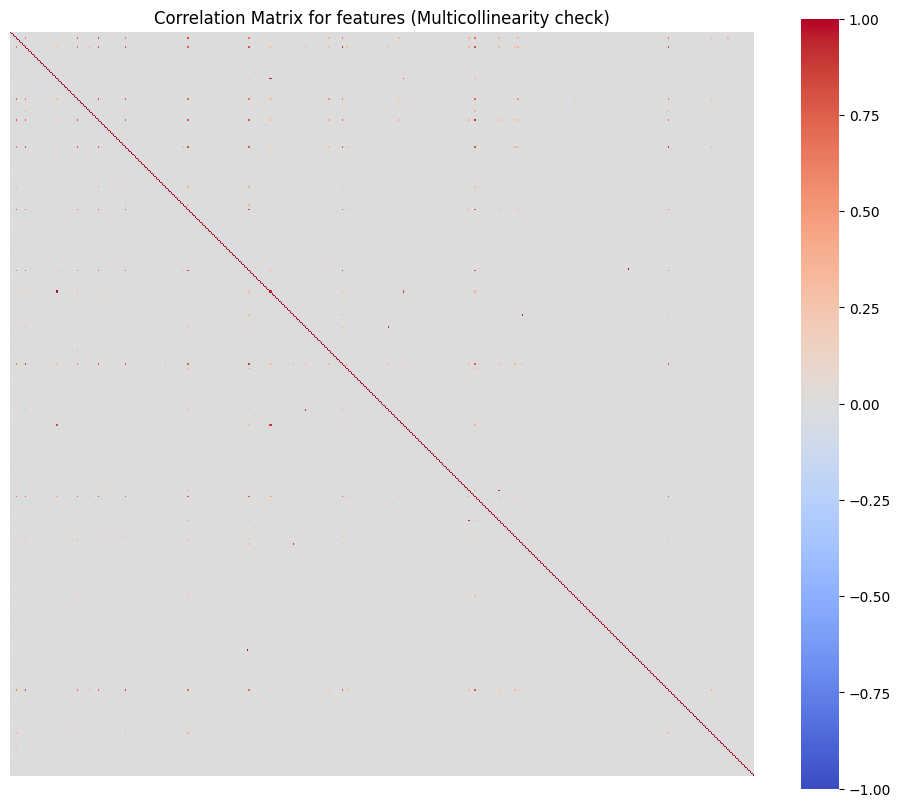

In [9]:
corr_matrix = X_train.corr()

plt.figure(figsize=(12, 10))

sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1, 
            square=True, linewidths=0, xticklabels=False, yticklabels=False)

plt.title("Correlation Matrix for features (Multicollinearity check)")
plt.show()

In [10]:
threshold = 0.80
highly_correlated_pairs = []

upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

for col in upper_triangle.columns:
    for row in upper_triangle.index:
        corr_value = upper_triangle.loc[row, col]
        if pd.notna(corr_value) and abs(corr_value) > threshold:
            highly_correlated_pairs.append((row, col, corr_value))

highly_correlated_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
print(f"\nPairs with strong correlation (|r| > {threshold})")
for var1, var2, val in highly_correlated_pairs:
    print(f"Variable {var1} and Variable {var2} (Correlation: {val:.2f})")

# We see that there are some highly correlared pairs of features


Pairs with strong correlation (|r| > 0.8)
Variable V32 and Variable V175 (Correlation: 1.00)
Variable V160 and Variable V416 (Correlation: 1.00)
Variable V32 and Variable V176 (Correlation: 0.92)
Variable V175 and Variable V176 (Correlation: 0.92)
Variable V191 and Variable V345 (Correlation: 0.91)
Variable V176 and Variable V265 (Correlation: 0.91)
Variable V309 and Variable V329 (Correlation: 0.91)
Variable V199 and Variable V255 (Correlation: 0.91)
Variable V60 and Variable V313 (Correlation: 0.89)
Variable V78 and Variable V443 (Correlation: 0.88)
Variable V11 and Variable V224 (Correlation: 0.88)
Variable V161 and Variable V224 (Correlation: 0.87)
Variable V11 and Variable V443 (Correlation: 0.84)
Variable V120 and Variable V161 (Correlation: 0.84)
Variable V32 and Variable V265 (Correlation: 0.84)
Variable V175 and Variable V265 (Correlation: 0.84)
Variable V78 and Variable V120 (Correlation: 0.84)
Variable V46 and Variable V60 (Correlation: 0.83)
Variable V5 and Variable V60 (C

### Outlier search

In [11]:
# Amount of outliers in the training data (using 3 standard deviations as the threshold)
outliers = (X_train < (X_train.mean() - 3 * X_train.std())) | (X_train > (X_train.mean() + 3 * X_train.std()))
outlier_counts = outliers.sum()
print("\nNumber of outliers in each feature (decreasing order):")
print(outlier_counts.sort_values(ascending=False))


Number of outliers in each feature (decreasing order):
V416    97
V160    97
V390    93
V311    88
V199    74
        ..
V465     0
V461     0
V23      0
V1       0
V500     0
Length: 500, dtype: int64


# Some experiments with different setups

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from src.utils import calculate_profit

### Baseline campaign model - dummy, default LogisticRegression with top 5 variables correlated to y

In [13]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=67, stratify=y_train
)
correlations = df_eda.corr()['y'].drop('y')
top_correlations = correlations.abs().sort_values(ascending=False).head(5)
features_to_use = top_correlations.index.tolist()

X_train_baseline = X_train[features_to_use]
X_val_baseline = X_val[features_to_use]

model_baseline = LogisticRegression()
model_baseline.fit(X_train_baseline, y_train.values.ravel())

y_val_pred_proba = model_baseline.predict_proba(X_val_baseline)[:, 1]

baseline_score = calculate_profit(
    y_true=y_val, 
    y_pred_proba=y_val_pred_proba, 
    num_vars=len(features_to_use), 
    debug=True
)

### Same for 1 variable

In [14]:

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=67, stratify=y_train
)
correlations = df_eda.corr()['y'].drop('y')
top_correlations = correlations.abs().sort_values(ascending=False).head(1)
features_to_use = top_correlations.index.tolist()

X_train_baseline = X_train[features_to_use]
X_val_baseline = X_val[features_to_use]

model_baseline = LogisticRegression()
model_baseline.fit(X_train_baseline, y_train.values.ravel())

y_val_pred_proba = model_baseline.predict_proba(X_val_baseline)[:, 1]

baseline_score = calculate_profit(
    y_true=y_val, 
    y_pred_proba=y_val_pred_proba, 
    num_vars=len(features_to_use), 
    debug=True
)

### Lasso regularization used for feature selection

In [15]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=67, stratify=y_train
)

model_baseline = LogisticRegression(penalty='l1', solver='saga', max_iter=5000, l1_ratio=1.0, C=0.01)
model_baseline.fit(X_train, y_train.values.ravel())
no_zero_coef_indices = np.where(model_baseline.coef_[0] != 0)[0]
features_to_use = X_train.columns[no_zero_coef_indices].tolist()

y_val_pred_proba = model_baseline.predict_proba(X_val)[:, 1]

baseline_score = calculate_profit(
    y_true=y_val, 
    y_pred_proba=y_val_pred_proba, 
    num_vars=len(features_to_use), 
    debug=True
)

C:\Users\anost\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [16]:
# l1 reg with strong regularization to get very few features

model_baseline = LogisticRegression(penalty='l1', solver='saga', max_iter=1000, l1_ratio=1.0, C=0.01)
model_baseline.fit(X_train, y_train.values.ravel())

no_zero_coef_indices = np.where(model_baseline.coef_[0] != 0)[0]
features_to_use = X_train.columns[no_zero_coef_indices].tolist()

y_val_pred_proba = model_baseline.predict_proba(X_val)[:, 1]
baseline_score = calculate_profit(
    y_true=y_val, 
    y_pred_proba=y_val_pred_proba, 
    num_vars=len(features_to_use), 
    debug=True
)

C:\Users\anost\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [17]:
!pip install boruta

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\anost\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


### Boruta feature selector

In [18]:
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier

rf_estimator = RandomForestClassifier(
	n_estimators=200,
	random_state=67,
	n_jobs=-1,
	class_weight='balanced'
)

boruta = BorutaPy(rf_estimator, n_estimators='auto', random_state=67)
boruta.fit(X_train.values, y_train.values.ravel())
features_to_use = X_train.columns[boruta.support_].tolist()
print(f"Features selected by Boruta: {features_to_use}")


Features selected by Boruta: ['V11', 'V117', 'V160', 'V161', 'V176', 'V191', 'V215', 'V224', 'V227', 'V255', 'V262', 'V265', 'V309', 'V329', 'V342', 'V345', 'V380', 'V390', 'V416', 'V483']


In [19]:
rf_estimator = RandomForestClassifier(
    n_estimators=100, 
    random_state=67, 
    n_jobs=-1, 
    class_weight='balanced',
    max_depth=5 
)

boruta = BorutaPy(rf_estimator, n_estimators='auto', random_state=67, max_iter=50)
boruta.fit(X_train.values, y_train.values.ravel())

confirmed_features = X_train.columns[boruta.support_].tolist()
tentative_features = X_train.columns[boruta.support_weak_].tolist()

print(f"Confirmed: {len(confirmed_features)}")
print(f"Tentative: {len(tentative_features)}")

ranking_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Ranking': boruta.ranking_
}).sort_values(by='Ranking')

print("Top Features:")
print(ranking_df.head(15))

Confirmed: 27
Tentative: 1
Top Features:
    Feature  Ranking
482    V483        1
389    V390        1
59      V60        1
379    V380        1
341    V342        1
344    V345        1
160    V161        1
226    V227        1
264    V265        1
261    V262        1
116    V117        1
119    V120        1
312    V313        1
308    V309        1
328    V329        1


In [20]:
from sklearn.ensemble import HistGradientBoostingClassifier

model_baseline_tree = HistGradientBoostingClassifier(
    max_iter=50,      
    max_depth=3,            
    min_samples_leaf=100,
    l2_regularization=2.0,  
    learning_rate=0.05,     
    random_state=67
)

model_baseline_tree.fit(X_train[confirmed_features], y_train.values.ravel())

train_accuracy = model_baseline_tree.score(X_train[confirmed_features], y_train.values.ravel())
val_accuracy = model_baseline_tree.score(X_val[confirmed_features], y_val.values.ravel())

y_pred_proba = model_baseline_tree.predict_proba(X_val[confirmed_features])[:, 1]

profit = calculate_profit(
    y_true=y_val.values.ravel(),
    y_pred_proba=y_pred_proba,
    num_vars=len(confirmed_features),
    debug=True
)

print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Profit: {profit:.2f}")

Train Accuracy: 0.7063
Validation Accuracy: 0.6687
Profit: -3830.00
